In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

print("Everything working ✅")

Everything working ✅


In [18]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn

In [19]:
import sys
print(sys.executable)

c:\Users\soumy\AppData\Local\Programs\Python\Python311\python.exe


In [20]:
!{sys.executable} -m pip show openpyxl

Name: openpyxl
Version: 3.1.5
Summary: A Python library to read/write Excel 2010 xlsx/xlsm files
Home-page: https://openpyxl.readthedocs.io
Author: See AUTHORS
Author-email: charlie.clark@clark-consulting.eu
License: MIT
Location: c:\Users\soumy\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: et-xmlfile
Required-by: 


In [21]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install openpyxl

In [22]:
!{sys.executable} -m pip show openpyxl

Name: openpyxl
Version: 3.1.5
Summary: A Python library to read/write Excel 2010 xlsx/xlsm files
Home-page: https://openpyxl.readthedocs.io
Author: See AUTHORS
Author-email: charlie.clark@clark-consulting.eu
License: MIT
Location: c:\Users\soumy\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: et-xmlfile
Required-by: 


In [23]:
daily = pd.read_excel(r"C:\Users\soumy\Downloads\Aurika\data\daily_covers.xlsx")
res = pd.read_excel(r"C:\Users\soumy\Downloads\Aurika\data\reservations.xlsx")

daily.head()

,date,covers_count,checks_count,avg_check,food_sales,beverage_sales,gross_sales,is_complete,anomaly_flag,notes
0,2022-01-01,206,77,79.45,8814.52,7755.14,16613.73,True,NaN,NaN
1,2022-01-02,170,57,72.86,6275.01,5658.69,11853.41,True,NaN,NaN
2,2022-01-04,78,22,86.43,3993.92,2831.38,6793.52,True,NaN,NaN
3,2022-01-05,94,35,75.32,4264.62,2609.28,6944.48,True,NaN,NaN
4,2022-01-06,99,38,84.60,4425.16,3613.01,8006.55,True,NaN,NaN


In [24]:
!{sys.executable} -m pip list

Package                 Version
----------------------- -----------
asttokens               3.0.1
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
et_xmlfile              2.0.0
executing               2.2.1
fonttools               4.62.1
ipykernel               7.2.0
ipython                 9.10.1
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.5.0
matplotlib              3.10.8
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.4.4
openpyxl                3.1.5
packaging               26.0
pandas                  3.0.2
parso                   0.8.6
pillow                  12.2.0
pip                     26.0.1
platformdirs            4.9.4
prompt_toolkit          3.0.52
psutil                  

In [25]:
daily = pd.read_excel(r"C:\Users\soumy\Downloads\Aurika\data\daily_covers.xlsx")
res = pd.read_excel(r"C:\Users\soumy\Downloads\Aurika\data\reservations.xlsx")

# Convert to datetime
daily['date'] = pd.to_datetime(daily['date'])
res['date'] = pd.to_datetime(res['date'])
res['booked_at'] = pd.to_datetime(res['booked_at'], errors='coerce')

daily.head()

,date,covers_count,checks_count,avg_check,food_sales,beverage_sales,gross_sales,is_complete,anomaly_flag,notes
0,2022-01-01,206,77,79.45,8814.52,7755.14,16613.73,True,NaN,NaN
1,2022-01-02,170,57,72.86,6275.01,5658.69,11853.41,True,NaN,NaN
2,2022-01-04,78,22,86.43,3993.92,2831.38,6793.52,True,NaN,NaN
3,2022-01-05,94,35,75.32,4264.62,2609.28,6944.48,True,NaN,NaN
4,2022-01-06,99,38,84.60,4425.16,3613.01,8006.55,True,NaN,NaN


In [26]:
daily = pd.read_excel(r"C:\Users\soumy\Downloads\Aurika\data\daily_covers.xlsx")
res = pd.read_excel(r"C:\Users\soumy\Downloads\Aurika\data\reservations.xlsx")

daily['date'] = pd.to_datetime(daily['date'])
res['date'] = pd.to_datetime(res['date'])
res['booked_at'] = pd.to_datetime(res['booked_at'], errors='coerce')

daily.head()

,date,covers_count,checks_count,avg_check,food_sales,beverage_sales,gross_sales,is_complete,anomaly_flag,notes
0,2022-01-01,206,77,79.45,8814.52,7755.14,16613.73,True,NaN,NaN
1,2022-01-02,170,57,72.86,6275.01,5658.69,11853.41,True,NaN,NaN
2,2022-01-04,78,22,86.43,3993.92,2831.38,6793.52,True,NaN,NaN
3,2022-01-05,94,35,75.32,4264.62,2609.28,6944.48,True,NaN,NaN
4,2022-01-06,99,38,84.60,4425.16,3613.01,8006.55,True,NaN,NaN


In [27]:
print("Daily shape:", daily.shape)
print("Reservations shape:", res.shape)

print(daily.isna().sum())
print(res.isna().sum())

res['status'].value_counts()

Daily shape: (626, 10)
Reservations shape: (37891, 7)
date                0
covers_count        0
checks_count        0
avg_check           0
food_sales          0
beverage_sales      0
gross_sales         0
is_complete         0
anomaly_flag      616
notes             616
dtype: int64
reservation_id       0
date                 0
party_size           0
status               0
arrival_time      1525
booked_at          764
is_vip               0
dtype: int64


status
confirmed    31224
no_show       4361
cancelled     1165
pending       1141
Name: count, dtype: int64

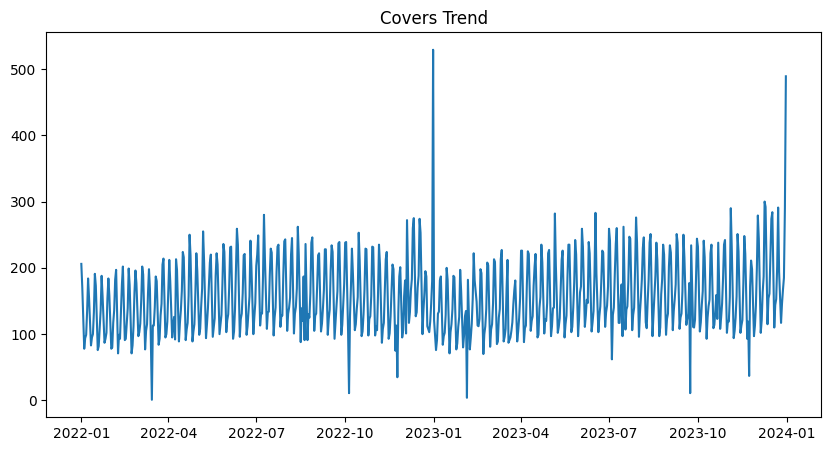

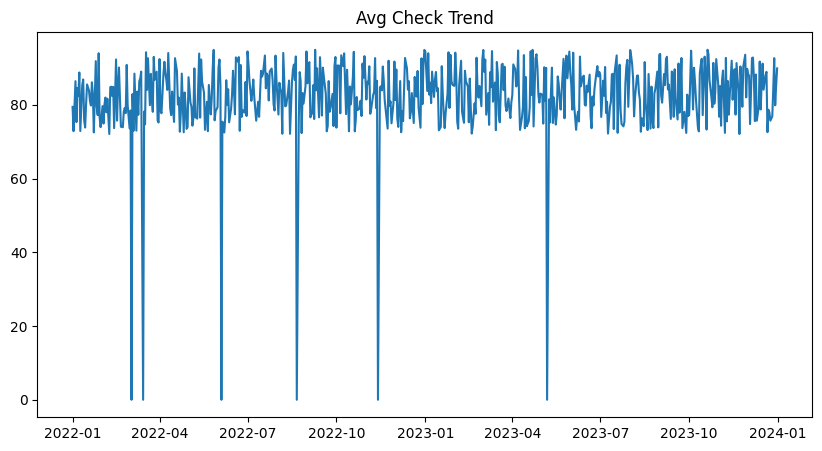

In [28]:
plt.figure(figsize=(10,5))
plt.plot(daily['date'], daily['covers_count'])
plt.title("Covers Trend")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(daily['date'], daily['avg_check'])
plt.title("Avg Check Trend")
plt.show()

In [29]:
# Remove incomplete days
daily = daily[daily['is_complete'] == True]

# Remove invalid values
daily = daily[(daily['avg_check'] > 0) & (daily['covers_count'] > 0)]

# Remove anomaly rows if flagged
daily = daily[daily['anomaly_flag'].isna()]

# Remove buyout events
daily = daily[daily['notes'] != 'buyout']

In [30]:
# Keep only relevant statuses
res = res[res['status'].isin(['confirmed', 'no_show'])]

# Lead time
res['lead_time'] = (res['date'] - res['booked_at']).dt.days

# Handle missing
res['lead_time'] = res['lead_time'].fillna(0)
res['arrival_time'] = res['arrival_time'].fillna("unknown")

In [31]:
# Rolling features (VERY POWERFUL)
df['rolling_mean_7'] = df['covers_count'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['covers_count'].shift(1).rolling(7).std()

# Reservation intensity
df['reservation_per_person'] = df['total_reservations'] / (df['total_party'] + 1)

# VIP ratio
df['vip_ratio'] = df['vip_count'] / (df['total_reservations'] + 1)

df = df.dropna()

NameError: name 'df' is not defined

In [32]:
daily['day_of_week'] = daily['date'].dt.dayofweek

In [33]:
res_daily = res.groupby('date').agg({
    'party_size': 'sum',
    'reservation_id': 'count',
    'is_vip': 'sum',
    'lead_time': 'mean'
}).reset_index()

In [34]:
df = pd.merge(daily, res_daily, on='date', how='left')
df.fillna(0, inplace=True)
df = df.sort_values('date')

TypeError: Invalid value '0' for dtype 'str'. Value should be a string or missing value, got 'int' instead.

In [35]:
df['rolling_mean_7'] = df['covers_count'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['covers_count'].shift(1).rolling(7).std()

df['reservation_per_person'] = df['total_reservations'] / (df['total_party'] + 1)
df['vip_ratio'] = df['vip_count'] / (df['total_reservations'] + 1)

df = df.dropna()

KeyError: 'total_reservations'

In [36]:
res_daily = res.groupby('date').agg({
    'party_size': 'sum',
    'reservation_id': 'count',
    'is_vip': 'sum',
    'lead_time': 'mean'
}).reset_index()

res_daily.columns = [
    'date',
    'total_party',
    'total_reservations',
    'vip_count',
    'avg_lead_time'
]

res_daily.head()

,date,total_party,total_reservations,vip_count,avg_lead_time
0,2022-01-01,238,78,4,5.269231
1,2022-01-02,221,68,3,4.691176
2,2022-01-04,119,32,4,7.500000
3,2022-01-05,119,35,4,6.657143
4,2022-01-06,114,36,2,8.166667


In [37]:
df = pd.merge(daily, res_daily, on='date', how='left')

In [39]:
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(0)

df = df.sort_values('date')

In [40]:
print(df.columns)

Index(['date', 'covers_count', 'checks_count', 'avg_check', 'food_sales',
       'beverage_sales', 'gross_sales', 'is_complete', 'anomaly_flag', 'notes',
       'day_of_week', 'total_party', 'total_reservations', 'vip_count',
       'avg_lead_time'],
      dtype='str')


In [42]:
df['rolling_mean_7'] = df['covers_count'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['covers_count'].shift(1).rolling(7).std()

df['reservation_per_person'] = df['total_reservations'] / (df['total_party'] + 1)
df['vip_ratio'] = df['vip_count'] / (df['total_reservations'] + 1)

df = df.dropna()

In [43]:
split_date = df['date'].quantile(0.8)

train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]

In [44]:
features = [
    'day_of_week', 'month', 'weekend',
    'total_party', 'total_reservations',
    'vip_count', 'avg_lead_time',
    'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7',
    'reservation_per_person', 'vip_ratio'
]

X_train = train[features]
X_test = test[features]

KeyError: "['month', 'weekend', 'lag_7', 'lag_14'] not in index"

In [45]:
# Time features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Lag features
df = df.sort_values('date')

df['lag_7'] = df['covers_count'].shift(7)
df['lag_14'] = df['covers_count'].shift(14)

In [46]:
df['rolling_mean_7'] = df['covers_count'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['covers_count'].shift(1).rolling(7).std()

df['reservation_per_person'] = df['total_reservations'] / (df['total_party'] + 1)
df['vip_ratio'] = df['vip_count'] / (df['total_reservations'] + 1)

df = df.dropna()

In [47]:
print(df.columns)

Index(['date', 'covers_count', 'checks_count', 'avg_check', 'food_sales',
       'beverage_sales', 'gross_sales', 'is_complete', 'anomaly_flag', 'notes',
       'day_of_week', 'total_party', 'total_reservations', 'vip_count',
       'avg_lead_time', 'rolling_mean_7', 'rolling_std_7',
       'reservation_per_person', 'vip_ratio', 'month', 'weekend', 'lag_7',
       'lag_14'],
      dtype='str')


In [48]:
split_date = df['date'].quantile(0.8)

train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]

In [49]:
X_train = train[features]
X_test = test[features]

In [50]:
from xgboost import XGBRegressor

y_train = train['covers_count']
y_test = test['covers_count']

model = XGBRegressor(n_estimators=200, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

c:\Users\soumy\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:02:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:56: Empty dataset at worker: 0
  bst.update(dtrain, iteration=i, fobj=obj)


In [51]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
wmape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test)
bias = np.sum(y_pred - y_test) / np.sum(y_test)

print("COVERS MODEL")
print("MAE:", mae)
print("wMAPE:", wmape)
print("Bias:", bias)

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import joblib

In [13]:
daily = pd.read_excel(r"C:\Users\soumy\Downloads\Aurika\data\daily_covers.xlsx")
res = pd.read_excel(r"C:\Users\soumy\Downloads\Aurika\data\reservations.xlsx")

daily['date'] = pd.to_datetime(daily['date'])
res['date'] = pd.to_datetime(res['date'])
res['booked_at'] = pd.to_datetime(res['booked_at'], errors='coerce')

In [14]:
# Daily
daily = daily[daily['is_complete'] == True]
daily = daily[(daily['avg_check'] > 0) & (daily['covers_count'] > 0)]
daily = daily[daily['anomaly_flag'].isna()]
daily = daily[daily['notes'] != 'buyout']

# Reservations
res = res[res['status'].isin(['confirmed', 'no_show'])]

res['lead_time'] = (res['date'] - res['booked_at']).dt.days
res['lead_time'] = res['lead_time'].fillna(0)

res['arrival_time'] = res['arrival_time'].fillna("unknown")

In [15]:
daily['day_of_week'] = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
daily['weekend'] = daily['day_of_week'].isin([5,6]).astype(int)

In [16]:
res_daily = res.groupby('date').agg({
    'party_size': 'sum',
    'reservation_id': 'count',
    'is_vip': 'sum',
    'lead_time': 'mean'
}).reset_index()

res_daily.columns = [
    'date',
    'total_party',
    'total_reservations',
    'vip_count',
    'avg_lead_time'
]

In [17]:
df = pd.merge(daily, res_daily, on='date', how='left')

num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(0)

df = df.sort_values('date')

In [18]:
# Lag
df['lag_7'] = df['covers_count'].shift(7)
df['lag_14'] = df['covers_count'].shift(14)

# Rolling
df['rolling_mean_7'] = df['covers_count'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['covers_count'].shift(1).rolling(7).std()

# Ratios
df['reservation_per_person'] = df['total_reservations'] / (df['total_party'] + 1)
df['vip_ratio'] = df['vip_count'] / (df['total_reservations'] + 1)

# SAFE NaN handling (IMPORTANT FIX)
df = df.dropna(subset=['lag_7', 'lag_14', 'rolling_mean_7'])

df = df.fillna(0)

In [19]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Train:", len(train), "Test:", len(test))

Train: 474 Test: 119


In [20]:
features = [
    'day_of_week', 'month', 'weekend',
    'total_party', 'total_reservations',
    'vip_count', 'avg_lead_time',
    'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7',
    'reservation_per_person', 'vip_ratio'
]

X_train = train[features]
X_test = test[features]

In [21]:
y_train = train['covers_count']
y_test = test['covers_count']

model = XGBRegressor(n_estimators=200, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [22]:
mae = mean_absolute_error(y_test, y_pred)
wmape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test)
bias = np.sum(y_pred - y_test) / np.sum(y_test)

print("COVERS MODEL")
print("MAE:", mae)
print("wMAPE:", wmape)
print("Bias:", bias)

COVERS MODEL
MAE: 10.713436126708984
wMAPE: 0.06204491671546786
Bias: -0.016958411946147244


In [23]:
baseline = df.groupby('day_of_week')['covers_count'].mean()
test['baseline_pred'] = test['day_of_week'].map(baseline)

baseline_mae = mean_absolute_error(y_test, test['baseline_pred'])

print("Baseline MAE:", baseline_mae)
print("Model MAE:", mae)

Baseline MAE: 18.392553352193836
Model MAE: 10.713436126708984


In [24]:
y_train_check = train['avg_check']
y_test_check = test['avg_check']

model_check = XGBRegressor(n_estimators=200, max_depth=5)
model_check.fit(X_train, y_train_check)

y_pred_check = model_check.predict(X_test)

In [25]:
mae_check = mean_absolute_error(y_test_check, y_pred_check)
wmape_check = np.sum(np.abs(y_test_check - y_pred_check)) / np.sum(y_test_check)
bias_check = np.sum(y_pred_check - y_test_check) / np.sum(y_test_check)

print("AVG_CHECK MODEL")
print("MAE:", mae_check)
print("wMAPE:", wmape_check)
print("Bias:", bias_check)

AVG_CHECK MODEL
MAE: 6.031114545549665
wMAPE: 0.07228260217626638
Bias: 0.007612919080156944


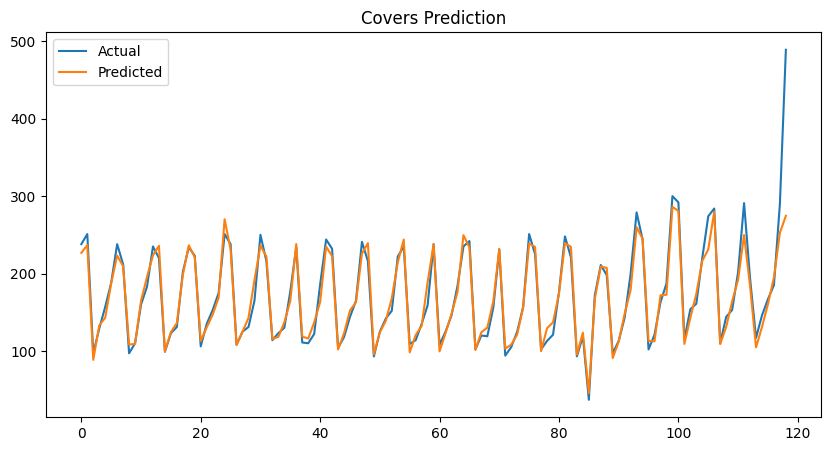

In [26]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Covers Prediction")
plt.show()

In [27]:
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

                   feature  importance
4       total_reservations    0.824610
3              total_party    0.131411
0              day_of_week    0.021224
1                    month    0.005312
9           rolling_mean_7    0.003226
7                    lag_7    0.002858
5                vip_count    0.002217
8                   lag_14    0.002183
11  reservation_per_person    0.002132
10           rolling_std_7    0.002019
6            avg_lead_time    0.001621
12               vip_ratio    0.001187
2                  weekend    0.000000


In [28]:
joblib.dump(model, "covers_model.pkl")
joblib.dump(model_check, "avg_check_model.pkl")

['avg_check_model.pkl']